<!--BOOK_INFORMATION-->
<img align="left" style="padding-right:10px;" src="figures/PDSH-cover-small.png">
*This notebook contains an excerpt from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas; the content is available [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).*

*The text is released under the [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode), and code is released under the [MIT license](https://opensource.org/licenses/MIT). If you find this content useful, please consider supporting the work by [buying the book](http://shop.oreilly.com/product/0636920034919.do)!*

<!--NAVIGATION-->
< [Customizing Colorbars](04.07-Customizing-Colorbars.ipynb) | [Contents](Index.ipynb) | [Text and Annotation](04.09-Text-and-Annotation.ipynb) >

# Multiple Subplots / 多子图

Sometimes it is helpful to compare different views of data side by side.
To this end, Matplotlib has the concept of *subplots*: groups of smaller axes that can exist together within a single figure.
These subplots might be insets, grids of plots, or other more complicated layouts.
In this section we'll explore four routines for creating subplots in Matplotlib.

In [2]:
# %matplotlib inline
import matplotlib.pyplot as plt
# plt.style.use('seaborn-white')
import numpy as np

## ``plt.axes``: Subplots by Hand / plt.axes：手动创建子图

The most basic method of creating an axes is to use the ``plt.axes`` function.
As we've seen previously, by default this creates a standard axes object that fills the entire figure.
``plt.axes`` also takes an optional argument that is a list of four numbers in the figure coordinate system.
These numbers represent ``[left, bottom, width, height]`` in the figure coordinate system, which ranges from 0 at the bottom left of the figure to 1 at the top right of the figure.

🐍 它还有一个可选参数，由图形坐标系统的四个值构成。这四个值分别表示图形坐标系统的 [bottom, left, width, height]（底坐标、左坐标、宽度、高度），数值的取值范围是左下角（原点）为 0，右上角为 1。

For example, we might create an inset axes at the top-right corner of another axes by setting the *x* and *y* position to 0.65 (that is, starting at 65% of the width and 65% of the height of the figure) and the *x* and *y* extents to 0.2 (that is, the size of the axes is 20% of the width and 20% of the height of the figure):

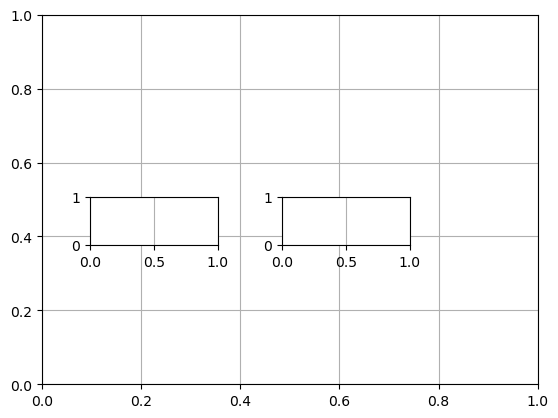

In [5]:
# plt.axes(bottom, left, width, height)

ax1 = plt.axes()  # standard axes
ax1.grid()

ax2 = plt.axes([0.5, 0.4, 0.2, 0.1]) # inset axes, 20% width and height of the main axes 
ax2.grid()

ax3 = plt.axes([0.2, 0.4, 0.2, 0.1]) # inset axes, 20% width and height of the main axes 
ax3.grid()

The equivalent of this command within the object-oriented interface is ``fig.add_axes()``. Let's use this to create two vertically stacked axes:

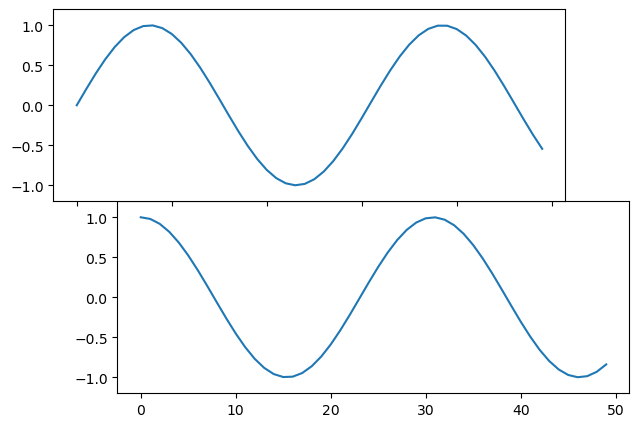

In [12]:
# fig.add_axes(left, bottom, width, height)

fig = plt.figure()

ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4],
                   ylim=(-1.2, 1.2))
ax1 = fig.add_axes([0.0, 0.5, 0.8, 0.4],
                   xticklabels=[], ylim=(-1.2, 1.2)) # 0.6=0.1+0.4+0.1

x = np.linspace(0, 10)
ax1.plot(np.sin(x))
ax2.plot(np.cos(x));

We now have two axes (the top with no tick labels) that are just touching: the bottom of the upper panel (at position 0.5) matches the top of the lower panel (at position 0.1 + 0.4).

## ``plt.subplot``: Simple Grids of Subplots / plt.subplot：简易网格子图

Aligned columns or rows of subplots are a common-enough need that Matplotlib has several convenience routines that make them easy to create.
The lowest level of these is ``plt.subplot()``, which creates a single subplot within a grid.
As you can see, this command takes three integer arguments—the number of rows, the number of columns, and the index of the plot to be created in this scheme, which runs from the upper left to the bottom right:

🐍 最底层的方法是用 plt.subplot() 在一个网格中创建一个子图, 三个整型参数——将要创建的网格子图行数、列数和索引值，索引值从 1 开始，从左上角到右下角依次增大

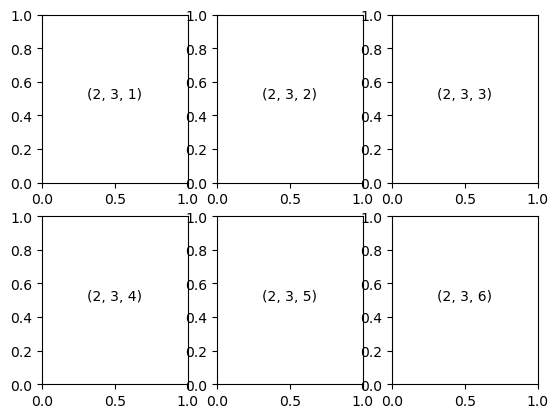

In [13]:
# plt.text(x, y, str(), fontsize=, ha='center' )

for i in range(1, 7):
    plt.subplot(2, 3, i)
    plt.text(0.5, 0.5, str((2, 3, i)),
             fontsize=10, ha='center')

The command ``plt.subplots_adjust`` can be used to adjust the spacing between these plots.
The following code uses the equivalent object-oriented command, ``fig.add_subplot()``:

🐍 plt.subplots_adjust 命令可以调整子图之间的间隔。用面向对象接口的命令 fig.add_subplot() 可以取得同样的效果

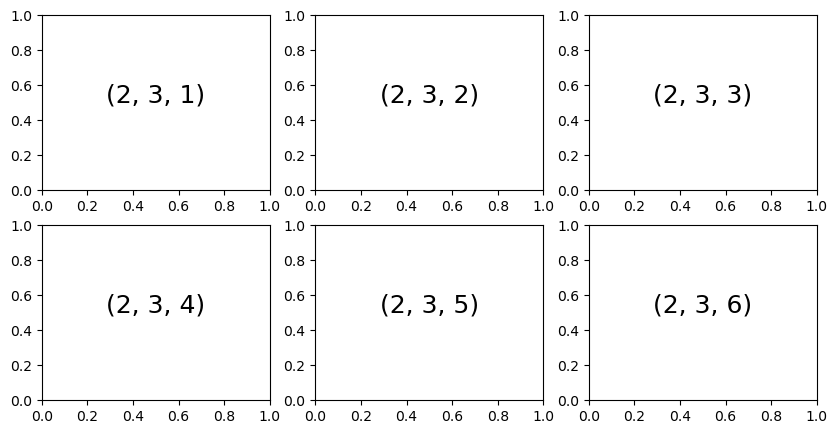

In [16]:
# plt.subplots_adjust()
# fig.add_subplots()

fig = plt.figure(figsize=(10, 5))
fig.subplots_adjust(hspace=0.2, wspace=0.2)
for i in range(1, 7):
    ax = fig.add_subplot(2, 3, i)
    ax.text(0.5, 0.5, str((2, 3, i)),
           fontsize=18, ha='center')

We've used the ``hspace`` and ``wspace`` arguments of ``plt.subplots_adjust``, which specify the spacing along the height and width of the figure, in units of the subplot size (in this case, the space is 40% of the subplot width and height).

## ``plt.subplots``: The Whole Grid in One Go /  用一行代码创建网格

The approach just described can become quite tedious when creating a large grid of subplots, especially if you'd like to hide the x- and y-axis labels on the inner plots.
For this purpose, ``plt.subplots()`` is the easier tool to use (note the ``s`` at the end of ``subplots``). Rather than creating a single subplot, this function creates a full grid of subplots in a single line, returning them in a NumPy array.
The arguments are the number of rows and number of columns, along with optional keywords ``sharex`` and ``sharey``, which allow you to specify the relationships between different axes.

🐍 plt.subplots() (需要注意此处 subplots 结尾多了个 s）用一行代码创建多个子图，并返回一个包含子图的 NumPy 数组。

🐍 关键参数是行数与列数，以及可选参数 sharex 与 sharey，通过它们可以设置不同子图之间的关联关系。

Here we'll create a $2 \times 3$ grid of subplots, where all axes in the same row share their y-axis scale, and all axes in the same column share their x-axis scale:

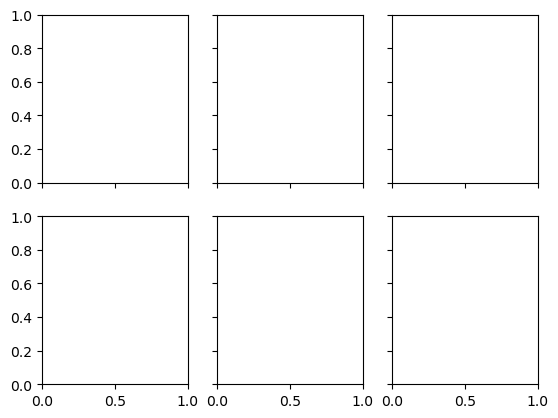

In [17]:
# plt.subplots(x, y, sharex='col', sharey='row')

fig, ax = plt.subplots(2, 3, sharex='col', sharey='row')

Note that by specifying ``sharex`` and ``sharey``, we've automatically removed inner labels on the grid to make the plot cleaner.
The resulting grid of axes instances is returned within a NumPy array, allowing for convenient specification of the desired axes using standard array indexing notation:

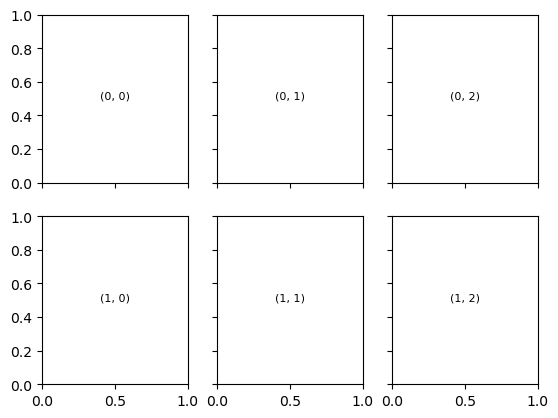

In [18]:
# axes are in a two-dimensional array, indexed by [row, col]
# 坐标轴存放在一个NumPy数组中，按照[row, col]取值
for i in range(2):
    for j in range(3):
        ax[i, j].text(0.5, 0.5, str((i, j)),
                      fontsize=8, ha='center')
fig

In comparison to ``plt.subplot()``, ``plt.subplots()`` is more consistent with Python's conventional 0-based indexing.

## ``plt.GridSpec``: More Complicated Arrangements / 实现更复杂的排列方式

To go beyond a regular grid to subplots that span multiple rows and columns, ``plt.GridSpec()`` is the best tool.
The ``plt.GridSpec()`` object does not create a plot by itself; it is simply a convenient interface that is recognized by the ``plt.subplot()`` command.
For example, a gridspec for a grid of two rows and three columns with some specified width and height space looks like this:

In [19]:
# plt.GridSpec(x, y, wspace= , hspace= )
# x行y列，等分

grid = plt.GridSpec(2, 5, wspace=0.4, hspace=0.2)

From this we can specify subplot locations and extents using the familiary Python slicing syntax:

🐍 可以通过类似 Python 切片的语法设置子图的位置和扩展尺寸

<Axes: >

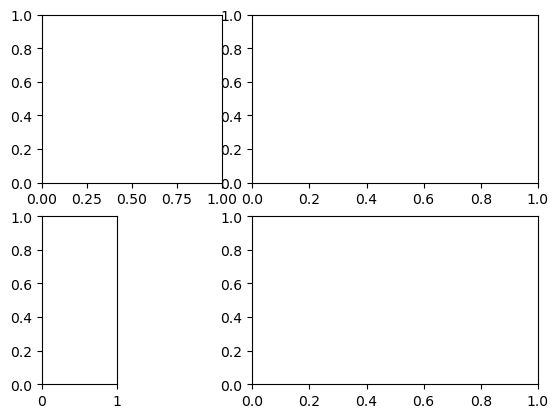

In [28]:
plt.subplot(grid[0, :2]) # 0行，0-2列
plt.subplot(grid[0, 2:]) # 0行，3-5列
plt.subplot(grid[1, 0]) # 1行，0列
plt.subplot(grid[1, 2:]) # 1行，2-5列

This type of flexible grid alignment has a wide range of uses.
I most often use it when creating multi-axes histogram plots like the ones shown here:

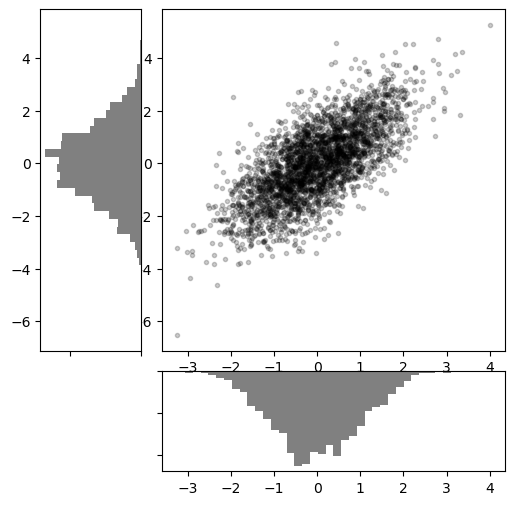

In [29]:
# Create some normally distributed data
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 3000).T

# Set up the axes with gridspec
fig = plt.figure(figsize=(6, 6))
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)
main_ax = fig.add_subplot(grid[:-1, 1:])
y_hist = fig.add_subplot(grid[:-1, 0], xticklabels=[], sharey=main_ax)
x_hist = fig.add_subplot(grid[-1, 1:], yticklabels=[], sharex=main_ax)

# scatter points on the main axes
main_ax.plot(x, y, 'ok', markersize=3, alpha=0.2)

# histogram on the attached axes
x_hist.hist(x, 40, histtype='stepfilled',
            orientation='vertical', color='gray')
x_hist.invert_yaxis()

y_hist.hist(y, 40, histtype='stepfilled',
            orientation='horizontal', color='gray')
y_hist.invert_xaxis()

This type of distribution plotted alongside its margins is common enough that it has its own plotting API in the Seaborn package; see [Visualization With Seaborn](04.14-Visualization-With-Seaborn.ipynb) for more details.

<!--NAVIGATION-->
< [Customizing Colorbars](04.07-Customizing-Colorbars.ipynb) | [Contents](Index.ipynb) | [Text and Annotation](04.09-Text-and-Annotation.ipynb) >